### 0. Plan
| Component | Engineering Choice | Core Citation Source |
| :--- | :--- | :--- |
| **Target Label** | Subreddit Median Normalization + 20% Quantile | Barnes et al. (2020) |
| **Data Split** | Strict Timeline Sort via `created_utc` | Savatteri et al. (2026) |
| **Semantic Features** | Fine-Tuned BERT Embeddings | Mouratidis et al. (2025) |
| **Linguistic Metrics** | Text-based LIWC Parameter Extraction | Vosoughi et al. (2018) |
| **Political Features** | Targeted UK Trigger Word Flags | Antypas et al. (2026) |
| **Classification Core** | XGBoost vs. Random Forest Baseline | Dogan et al. (2026) / Barnes et al. (2020) |
| **Primary Evaluation** | PR-AUC & Macro-F1 Optimization | Dogan et al. (2026) |
| **Explainability Engine** | Segmented Cross-Pipeline SHAP Evaluation | Lundberg & Lee (2017) / Hashmi et al. (2024) |

notes
- Sticking with same randomly split train/val/test datasets provided by fakeddit. I'm evaluating a static snapshot, not predicting temporal diffusion of a post. Analysing what structural and linguistic characteristics contribute to virality. Must use same datasets for pipeplines A and B to prevent cross-pipeline contamination.



In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns

In [23]:
data_dir = os.path.join('..', 'data', 'processed', 'US')

train_path = os.path.join(data_dir, 'multimodal_train.tsv')
val_path = os.path.join(data_dir, 'multimodal_validate.tsv')
test_path = os.path.join(data_dir, 'multimodal_test.tsv')

train_df = pd.read_csv(train_path, sep='\t')
val_df = pd.read_csv(val_path, sep='\t')
test_df = pd.read_csv(test_path, sep='\t')

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/US/multimodal_test.tsv'

In [3]:
train_df.head()

,author,clean_title,created_utc,domain,hasImage,id,image_url,linked_submission_id,num_comments,score,subreddit,title,upvote_ratio,2_way_label,3_way_label,6_way_label
0,Alexithymia,my walgreens offbrand mucinex was engraved wit...,1.551641e+09,i.imgur.com,True,awxhir,https://external-preview.redd.it/WylDbZrnbvZdB...,NaN,2.0,12,mildlyinteresting,My Walgreens offbrand Mucinex was engraved wit...,0.84,1,0,0
1,VIDCAs17,this concerned sink with a tiny hat,1.534727e+09,i.redd.it,True,98pbid,https://preview.redd.it/wsfx0gp0f5h11.jpg?widt...,NaN,2.0,119,pareidolia,This concerned sink with a tiny hat,0.99,0,2,2
2,prometheus1123,hackers leak emails from uae ambassador to us,1.496511e+09,aljazeera.com,True,6f2cy5,https://external-preview.redd.it/6fNhdbc6K1vFA...,NaN,1.0,44,neutralnews,Hackers leak emails from UAE ambassador to US,0.92,1,0,0
3,NaN,puppy taking in the view,1.471341e+09,i.imgur.com,True,4xypkv,https://external-preview.redd.it/HLtVNhTR6wtYt...,NaN,26.0,250,photoshopbattles,PsBattle: Puppy taking in the view,0.95,1,0,0
4,3rikR3ith,i found a face in my sheet music too,1.525318e+09,i.redd.it,True,8gnet9,https://preview.redd.it/ri7ut2wn8kv01.jpg?widt...,NaN,2.0,13,pareidolia,I found a face in my sheet music too!,0.84,0,2,2


### 1. Virality target construction 

Was going to use VAI (Chauhan et al., 2025) but they rely on post **age**, which I don't have as I'm using static snapshots. Instead, employ the methodology of **Barnes et al. (2020)** from Dank or Not meme paper.

They use feature extraction and then run both random forest and gradient boost models on the fulll feature set. They also use a dataset that's extracted from pushift - same as Fakeddit and my UK dataset so it's a good match.

Highly cited paper (72 citations) so an authoritative source in the research space

Construct virality labels
- Populatiry metric based on upvotes and number of comments - community engagement 
- Chauhan et al. 2025 use upvotes + num_comments in their VAI equation, then divide by age (in hrs). Won't be accounting for age since my snapshot is static. 
- Following Barnes et al (2020), raw engagement scores are normalised to reduce impact of subreddit size. To show why this is necessary, can follow their analysis: "To confirm this observation, we determined the median number of upvotes for each respective subreddit and calculated a Pearson correlation coefficient between these values and the number of subscribers for each subreddit.". **My data doesn't have subreddit subscriber counts, so need to use an alternative method to account for community size. Divide by median raw engagement score for the post's subreddit (acts as proxy for subscriber scale**

$$\text{Raw Engagement}_i = (1 \cdot \text{score}_i) + (1 \cdot \text{num\_comments}_i)$$

$$\text{Normalized Engagement}_i = \frac{\text{Raw Engagement}_i}{\text{Subreddit Median Raw Engagement Score}}$$

Virality threshold determined by k-means
- Following methodology of Dogan et al. 
- K = 2. Clustering algorithm deployed across whole dataset. Segmenting long-tailed distribution into two structural clusters - viral and non-viral. 
- Use 99th percentile outlier cap - k-menas heavily affected by extreme outliers. Apply cap to reduce their effect 
- Ensures threshold dictated by structure of user engagement data rather than unjustified empirical choice. 

In [26]:
def plot_engagement_dist(df, threshold):
    plot_df = pd.DataFrame({
        'Log_Capped_Engagement': df['log_capped_engagement'],
        'Class': df['is_viral'].map({0: "Non-Viral (0)", 1: 'Viral (1)'})
    })

    plt.figure(figsize=(8, 5))
    sns.set_theme(style='whitegrid')

    sns.histplot(
        data=plot_df,
        x='Log_Capped_Engagement',
        hue='Class',
        palette={'Non-Viral (0)': '#3498db', 'Viral (1)': '#e74c3c'},
        bins=50
    )

    # virality threshold line 
    plt.axvline(
        x=threshold, 
        color='#2c3e50',
        linestyle='--',
        linewidth=2.5,
        label=f'Virality Threshold ({threshold:.2f})'
    )

    plt.title('Data-Driven Virality Partitioning (Dogan et al. 2026 Framework)', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Log-Capped Normalised Engagement [ln(x + 1)]', fontsize=12, labelpad=10)
    plt.ylabel('Post Count (Frequency)', fontsize=12, labelpad=10)

    plt.legend(title='Class', title_fontsize='11', loc='upper right', frameon=True)

    plt.tight_layout()
    plt.show()



In [27]:
def calculate_engagement_k_means(df, percentile_cap=0.98, log_cap=True, graph=True):
    # raw engagement = num comments + score (num upvotes)
    df['raw_engagement'] = df['num_comments'] + df['score']
    df['raw_engagement'] = df['raw_engagement'].fillna(0)

    subreddit_medians = df.groupby(['subreddit'])['raw_engagement'].transform('median') # transform broadcasts medians across whole dataset - not collapsed by groupby
    df['normalised_engagement'] = df['raw_engagement']/(subreddit_medians + 1) # add 1 to avoid dividing my zero

    # apply percentile outlier cap to reduce the effects of outliers on k-means
    p_threshold = df['normalised_engagement'].quantile(percentile_cap)
    df['capped_engagement'] = np.minimum(df['normalised_engagement'], p_threshold) # use what's smaller of engagement number or 99% cap 
    if log_cap:
        # apply log transformation to engagement to further smooth distribution
        df['log_capped_engagement'] = np.log1p(df['capped_engagement'])
        engagement_matrix = df['log_capped_engagement'].values.reshape(-1, 1)
    else:
        # k-means thresholding - reshape array for scikit-learn
        engagement_matrix = df['capped_engagement'].values.reshape(-1, 1)

    # train k-means with 2 clusters - viral vs non-viral
    kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
    df['cluster_labels'] = kmeans.fit_predict(engagement_matrix)

    # map cluster labels to 'is_viral' df col
    cluster_centres = kmeans.cluster_centers_.flatten()
    viral_clusters = np.argmax(cluster_centres)     # seeing which cluster has the higher engagement metrics

    df['is_viral'] = (df['cluster_labels'] == viral_clusters).astype(int)


    threshold = np.mean(cluster_centres)
    print(f'Virality threshold identified at: {threshold:.2f}')
    print(f'Class distribution: {df['is_viral'].value_counts(normalize=True).to_dict()}')

    if graph:
        plot_engagement_dist(df, threshold)

    cols_to_drop = ['cluster_labels', 'log_capped_engagement', 'capped_engagement']
    df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

    return df, threshold

In [28]:
_ = calculate_engagement_k_means(train_df, percentile_cap=1, log_cap=True, graph=False)

Virality threshold identified at: 2.23
Class distribution: {0: 0.9231737588652482, 1: 0.07682624113475177}


Virality threshold identified at: 2.09
Class distribution: {0: 0.9157730496453901, 1: 0.08422695035460993}


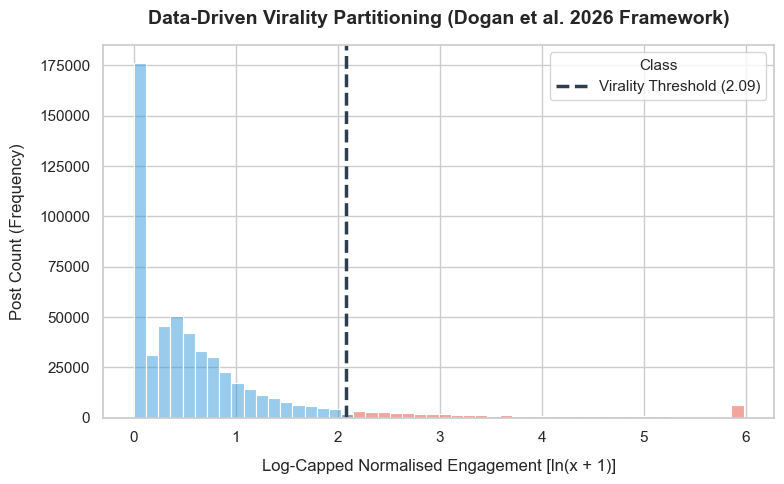

In [29]:
train_df, calc_virality_threshold = calculate_engagement_k_means(train_df, percentile_cap=0.99, log_cap=True)

In [7]:
_ = calculate_engagement_k_means(train_df, percentile_cap=0.99, log_cap=False)

Virality threshold identified at: 170.67
Class distribution: {0: 0.9828971631205674, 1: 0.017102836879432624}


- Initially applied 99% cap as done in paper, but viral class too small, too still heavily affected by outliers. Acute class imbalance would make downstream supervised learning difficult (justify)
- To further smooth the long tail variance, a natural log transformation was applied (ln(x+1))
- Experimentation with and without both the log and percentile caps suggested a log transform with a 99th percentile cap yileds a good class balance. 
    - virality threshold - 2.09 (approx 7.08 on normalised scale)
    - 8.42% viral posts

Plot distribution of normalised engagement scores, showing virality threshold and different coluors for binary virality classes

### 2. Experimental setup and chronological partitioning

To ensure absolute experimental validity and prevent temporal data leakage, the dataset is partitioned using a strict chronological split rather than a random assignment.

Execution: The unified dataset is sorted in ascending order based on the created_utc Unix timestamp.

Partitioning: The data is split on the timeline axis into a 70% training set, a 15% validation set, and a 15% terminal holdout test set. This ensures the pipeline evaluates predictive power on "future" data relative to the training history, mimicking a deployment environment (Savatteri et al., 2026).



### 3. Feature matrix construction 
The machine learning framework maps four distinct, early-available feature vectors to predict the binary target:

Textual Semantic Space: Dense 768-dimensional sentence embedding vectors extracted from the hidden states of your fine-tuned BERT architecture (clean_title for Fakeddit; combined_text for Pushshift) (Mouratidis et al., 2025).

Psycholinguistic Markers (LIWC): Percentage scores mapping emotional tones and affective states (e.g., anger, anxiety), capturing the emotional drivers behind viral cascades (Vosoughi et al., 2018).

Affective Polarization Markers (Trigger Words): Binary andm frequency feature flags tracking localized UK political keywords, directly implementing the causal framework of Antypas et al. (2026).

Structural Metadata: Tabular features derived directly from created_utc at the moment of submission (e.g., post_hour_of_day, day_of_week) alongside categorical indicators tracking the host subreddit (Barnes et al., 2020; Dogan et al., 2026).
Structural & Temporal Formatting (Adapting Barnes et al., 2020): Tabular features engineering directly from post metadata to capture community interaction behaviors:

Title Linguistics: Character length, word count (word_count), and uppercase letter ratios (capitalization trends).

Punctuation Signals: Frequency counts of exclamation marks (!) and question marks (?) to capture sensationalism.

Temporal Metadata: Extracted submission hour of the day (0-23), day of the week, and an is_weekend binary flag computed from created_utc.

Modality Constraints: The native hasImage binary flag to assess how visual formatting choices impact algorithmic acceleration.

### 4. Model Architecture & Evaluation

Framework: An optimized XGBoost Classifier cross-validated against a baseline Random Forest Classifier (Barnes et al., 2020; Dogan et al., 2026).

Metrics: Model optimization targets PR-AUC and Macro-F1 to correctly evaluate performance against the intentional 80/20 target class skew (Dogan et al., 2026).

Explainability: Post-hoc extraction of global and localized SHAP values, contrasting the feature profiles of authentic viral posts versus misinformation viral posts to map algorithmic bias (Lundberg & Lee, 2017; Hashmi et al., 2024).